____

# RVM (Relevance Vector Machine)
___

## **Aim :**  
### To demonstrate the implementation of Relevance Vector Machine (RVM) for multi-class classification and compare its performance with Support Vector Machine (SVM) using a real-world dataset.

___
## **Objectives :** 

- To load and explore the Optical Recognition of Handwritten Digits dataset.
- To perform exploratory data analysis (EDA) to understand the dataset characteristics.
- To preprocess the data appropriately for classification tasks.
- To split the dataset into training, validation, and testing sets.
- To train and evaluate SVM and RVM models for multi-class classification.
- To compare the performance metrics of SVM and RVM, including accuracy, precision, recall, and F1-score.
___

## **Dataset :**
### Optical Recognition of Handwritten Digits Dataset (from UCI Machine Learning Repository, available via scikit-learn)"

____
## **Dataset Description :**
#### The Optical Recognition of Handwritten Digits dataset consists of 5,620 samples of handwritten digits (0-9) collected from various writers using a pressure-sensitive tablet. Each sample is represented by 64 features, which are pixel intensities (8x8 grid) normalized to values between 0 and 16. The dataset has 10 classes corresponding to the digits 0 through 9. It is a balanced multi-class classification problem, suitable for comparing probabilistic classifiers like RVM with SVM. The dataset is real-world, derived from actual handwriting samples, and is commonly used for benchmarking digit recognition algorithms.

____
## **Procedure :**


## Step 1: Import Necessary Libraries

In [81]:
!pip install sklearn-rvm


In [82]:
# Correct import for this package version
from sklearn_rvm.em_rvm import EMRVC

print("EMRVC imported successfully!")

# Optional: check version indirectly or just confirm
import sklearn_rvm
print("sklearn_rvm package version:", sklearn_rvm.__version__)  # should be 0.1.1

EMRVC imported successfully!
sklearn_rvm package version: 0.1.1


In [83]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import confusion_matrix,accuracy_score,classification_report 

from sklearn.svm import SVC
from sklearn_rvm import  EMRVC # Relevance Vector Classifier from scikit-rvm


import warnings
warnings.filterwarnings('ignore')

## Step 2 : Load the Dataset 

In [84]:
# Load the Digits
digits = load_digits()
X = digits.data
y = digits.target

df = pd.DataFrame(X, columns=[f'pixel_{i}' for i in range(64)])
df['target'] = y


In [85]:
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
(df.head())


Dataset shape: (1797, 65)

First 5 rows:


,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,...,pixel_55,pixel_56,pixel_57,pixel_58,pixel_59,pixel_60,pixel_61,pixel_62,pixel_63,target
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4


In [86]:
print("\nDataset info:")
print(digits.DESCR)



Dataset info:
.. _digits_dataset:

Optical recognition of handwritten digits dataset
--------------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 1797
:Number of Attributes: 64
:Attribute Information: 8x8 image of integer pixels in the range 0..16.
:Missing Attribute Values: None
:Creator: E. Alpaydin (alpaydin '@' boun.edu.tr)
:Date: July; 1998

This is a copy of the test set of the UCI ML hand-written digits datasets
https://archive.ics.uci.edu/ml/datasets/Optical+Recognition+of+Handwritten+Digits

The data set contains images of hand-written digits: 10 classes where
each class refers to a digit.

Preprocessing programs made available by NIST were used to extract
normalized bitmaps of handwritten digits from a preprinted form. From a
total of 43 people, 30 contributed to the training set and different 13
to the test set. 32x32 bitmaps are divided into nonoverlapping blocks of
4x4 and the number of on pixels are counted in each block. This 

## Step 3: Exploratory Data Analysis (EDA)

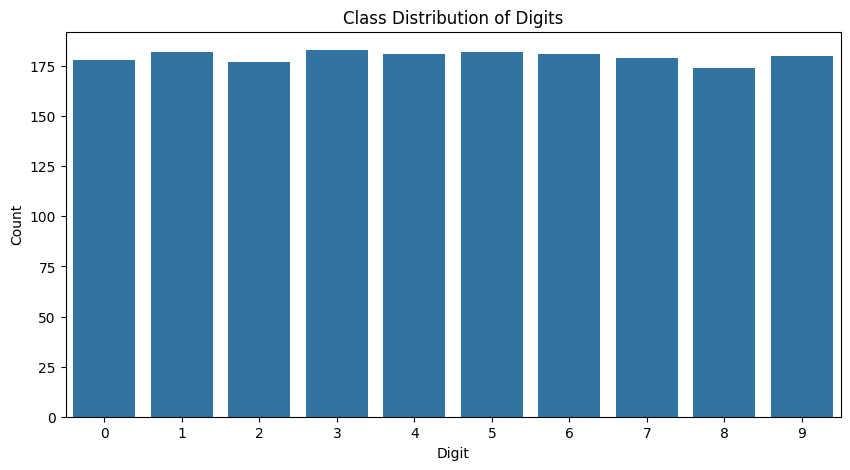

In [87]:
# Class distribution
plt.figure(figsize=(10, 5))
sns.countplot(x='target', data=df)
plt.title('Class Distribution of Digits')
plt.xlabel('Digit')
plt.ylabel('Count')
plt.show()

In [88]:
# Basic statistics
print("Dataset Statistics:")
(df.describe())

Dataset Statistics:


,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,...,pixel_55,pixel_56,pixel_57,pixel_58,pixel_59,pixel_60,pixel_61,pixel_62,pixel_63,target
count,1797.0,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,...,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000
mean,0.0,0.303840,5.204786,11.835838,11.848080,5.781859,1.362270,0.129661,0.005565,1.993879,...,0.206455,0.000556,0.279354,5.557596,12.089037,11.809126,6.764051,2.067891,0.364496,4.490818
std,0.0,0.907192,4.754826,4.248842,4.287388,5.666418,3.325775,1.037383,0.094222,3.196160,...,0.984401,0.023590,0.934302,5.103019,4.374694,4.933947,5.900623,4.090548,1.860122,2.865304
min,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.0,0.000000,1.000000,10.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,11.000000,10.000000,0.000000,0.000000,0.000000,2.000000
50%,0.0,0.000000,4.000000,13.000000,13.000000,4.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,4.000000,13.000000,14.000000,6.000000,0.000000,0.000000,4.000000
75%,0.0,0.000000,9.000000,15.000000,15.000000,11.000000,0.000000,0.000000,0.000000,3.000000,...,0.000000,0.000000,0.000000,10.000000,16.000000,16.000000,12.000000,2.000000,0.000000,7.000000
max,0.0,8.000000,16.000000,16.000000,16.000000,16.000000,16.000000,15.000000,2.000000,16.000000,...,13.000000,1.000000,9.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,9.000000


In [89]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1797 entries, 0 to 1796
Data columns (total 65 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   pixel_0   1797 non-null   float64
 1   pixel_1   1797 non-null   float64
 2   pixel_2   1797 non-null   float64
 3   pixel_3   1797 non-null   float64
 4   pixel_4   1797 non-null   float64
 5   pixel_5   1797 non-null   float64
 6   pixel_6   1797 non-null   float64
 7   pixel_7   1797 non-null   float64
 8   pixel_8   1797 non-null   float64
 9   pixel_9   1797 non-null   float64
 10  pixel_10  1797 non-null   float64
 11  pixel_11  1797 non-null   float64
 12  pixel_12  1797 non-null   float64
 13  pixel_13  1797 non-null   float64
 14  pixel_14  1797 non-null   float64
 15  pixel_15  1797 non-null   float64
 16  pixel_16  1797 non-null   float64
 17  pixel_17  1797 non-null   float64
 18  pixel_18  1797 non-null   float64
 19  pixel_19  1797 non-null   float64
 20  pixel_20  1797 non-null   floa

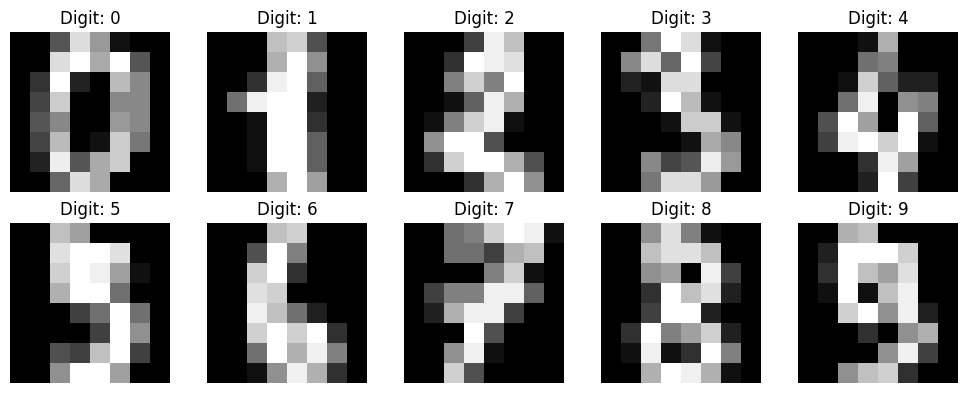

In [90]:
# Visualize sample images
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    img = digits.images[i]
    ax.imshow(img, cmap='gray')
    ax.set(title=f'Digit: {digits.target[i]}')
    ax.axis('off')
plt.tight_layout()
plt.show()

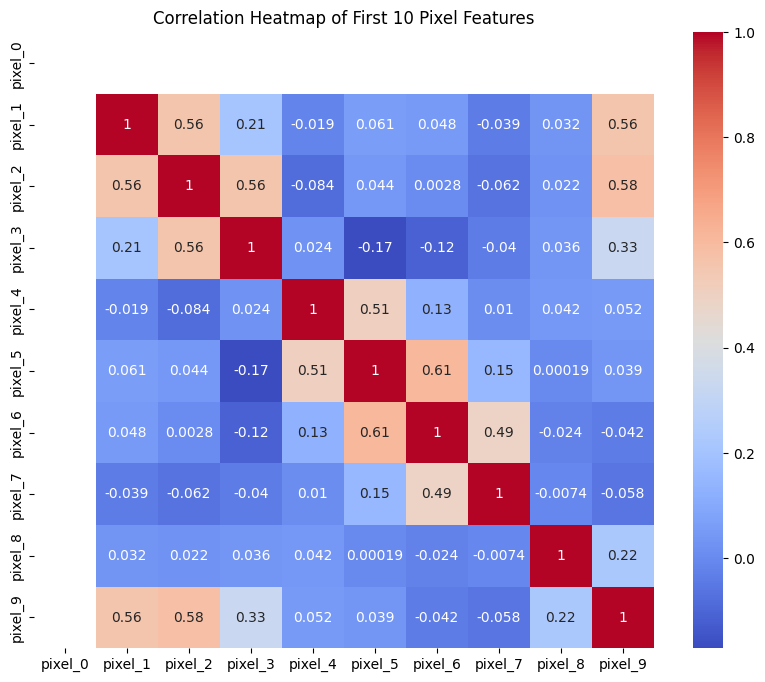

In [91]:
#  Correlation heatmap for first 10 features
plt.figure(figsize=(10 , 8))
sns.heatmap(df.iloc[:,:10].corr(), annot = True, cmap= 'coolwarm')
plt.title('Correlation Heatmap of First 10 Pixel Features')
plt.show()

## Step 4: Data Preprocessing

Although the pixel values are already normalized (0-16), we apply StandardScaler to standardize the features to zero mean and unit variance, which can improve model performance for SVM and RVM. No missing values or outliers need handling in this dataset.

In [92]:
# Initialize scaler
scaler = StandardScaler()

# Fit and transform the features
X_scaled = scaler.fit_transform(X)

print("Original data shape:", X.shape)
print("Scaled data shape:", X_scaled.shape)
print("Sample scaled features (first 5):")
print(X_scaled[:1, :5])

Original data shape: (1797, 64)
Scaled data shape: (1797, 64)
Sample scaled features (first 5):
[[ 0.         -0.33501649 -0.04308102  0.27407152 -0.66447751]]


## Step 5: Split the Dataset into Training, Validation, and Testing Sets

In [93]:
# Split into train + val and test (70-30)
X_temp, X_test, y_temp, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42, stratify=y)

# Split temp into train and val (70-15 overall, so 23.33% of total for val)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.23/0.7, random_state=42, stratify=y_temp)  # Approx 15% val

print("Training set shape:", X_train.shape)
print("Validation set shape:", X_val.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (843, 64)
Validation set shape: (414, 64)
Testing set shape: (540, 64)


## Step 6: Train and Evaluate SVM Model

SVM Validation Accuracy: 0.9782608695652174
SVM Test Accuracy: 0.975925925925926

SVM Classification Report (Test Set):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        54
           1       0.95      0.98      0.96        55
           2       1.00      0.98      0.99        53
           3       1.00      1.00      1.00        55
           4       0.94      0.94      0.94        54
           5       0.98      0.98      0.98        55
           6       0.98      1.00      0.99        54
           7       0.95      0.98      0.96        54
           8       1.00      0.92      0.96        52
           9       0.96      0.96      0.96        54

    accuracy                           0.98       540
   macro avg       0.98      0.98      0.98       540
weighted avg       0.98      0.98      0.98       540



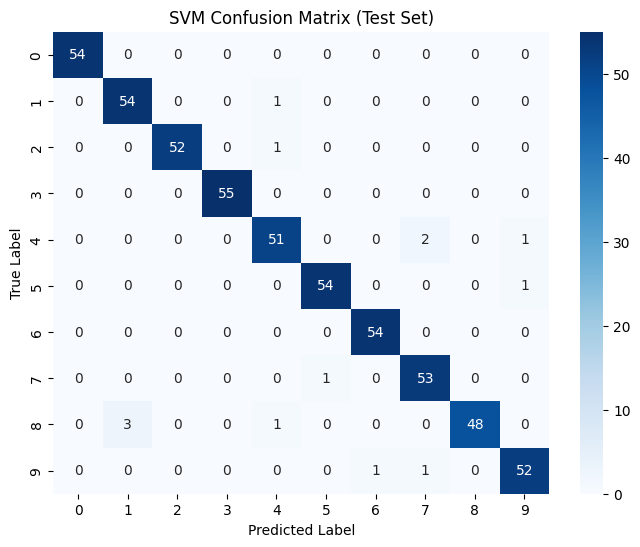

In [94]:
# Initialize SVM
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)

# Train on training set
svm_model.fit(X_train, y_train)

# Predict on validation set
y_val_pred_svm = svm_model.predict(X_val)
val_accuracy_svm = accuracy_score(y_val, y_val_pred_svm)

# Predict on test set
y_test_pred_svm = svm_model.predict(X_test)
test_accuracy_svm = accuracy_score(y_test, y_test_pred_svm)

print("SVM Validation Accuracy:", val_accuracy_svm)
print("SVM Test Accuracy:", test_accuracy_svm)
print("\nSVM Classification Report (Test Set):")
print(classification_report(y_test, y_test_pred_svm))

# Confusion Matrix for SVM (Test Set)
cm_svm = confusion_matrix(y_test, y_test_pred_svm)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues')
plt.title('SVM Confusion Matrix (Test Set)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

## Step 7: Train and Evaluate RVM Model

RVM Validation Accuracy: 0.9541062801932367
RVM Test Accuracy: 0.9481481481481482

RVM Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.96      0.94      0.95        54
           1       0.87      0.95      0.90        55
           2       1.00      0.98      0.99        53
           3       1.00      0.98      0.99        55
           4       0.93      0.96      0.95        54
           5       0.96      0.98      0.97        55
           6       0.95      0.96      0.95        54
           7       0.92      1.00      0.96        54
           8       0.93      0.81      0.87        52
           9       0.98      0.91      0.94        54

    accuracy                           0.95       540
   macro avg       0.95      0.95      0.95       540
weighted avg       0.95      0.95      0.95       540



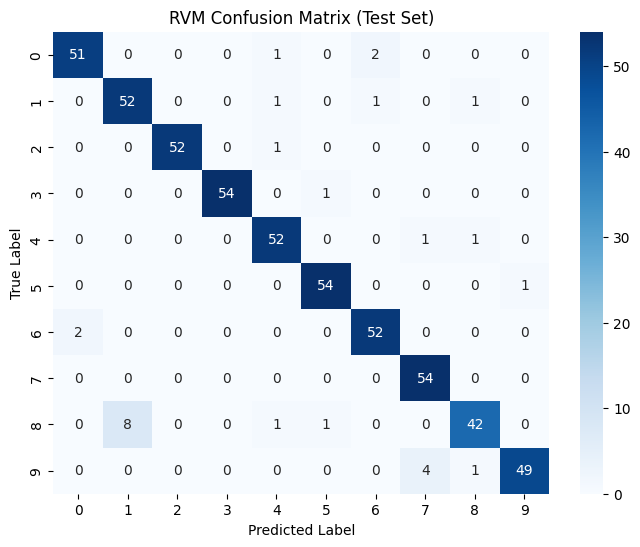

In [95]:
# Initialize RVM (Relevance Vector Classifier)
rvm_model = EMRVC(kernel='rbf', threshold_alpha=1e10, max_iter=10000, verbose=False) # Default RBF kernel

# Train on training set
rvm_model.fit(X_train, y_train)

# Predict on validation set
y_val_pred_rvm = rvm_model.predict(X_val)
val_accuracy_rvm = accuracy_score(y_val, y_val_pred_rvm)

# Predict on test set
y_test_pred_rvm = rvm_model.predict(X_test)
test_accuracy_rvm = accuracy_score(y_test, y_test_pred_rvm)

print("RVM Validation Accuracy:", val_accuracy_rvm)
print("RVM Test Accuracy:", test_accuracy_rvm)
print("\nRVM Classification Report (Test Set):")
print(classification_report(y_test, y_test_pred_rvm))

# Confusion Matrix for RVM (Test Set)
cm_rvm = confusion_matrix(y_test, y_test_pred_rvm)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rvm, annot=True, fmt='d', cmap='Blues')
plt.title('RVM Confusion Matrix (Test Set)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

## Step 8: Compare SVM and RVM Results

Model Comparison:
  Model  Validation Accuracy  Test Accuracy
0   SVM               0.9783         0.9759
1   RVM               0.9541         0.9481


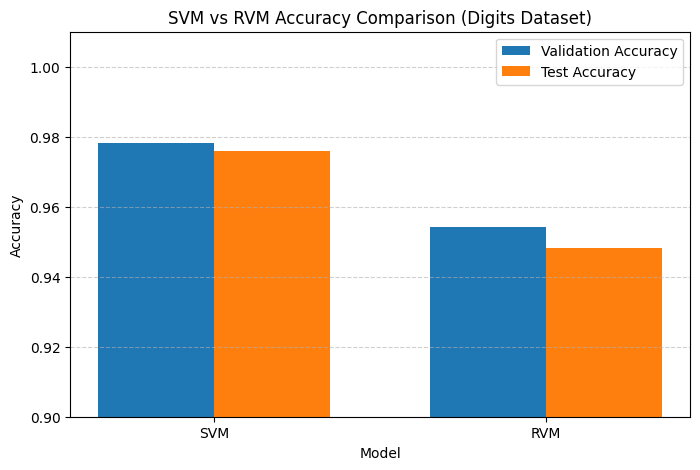

AttributeError: 'EMRVC' object has no attribute 'relevance_vectors_'

In [96]:
## Step 8: Compare SVM and RVM Results
"""
We now compare SVM and RVM based on performance (accuracy) and model sparsity — one of the main advantages of RVM is that it typically uses far fewer basis vectors (relevance vectors) than SVM uses support vectors, leading to a sparser, more interpretable, and potentially faster-at-inference model.

```python"""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Comparison Table
comparison_data = {
    'Model': ['SVM', 'RVM'],
    'Validation Accuracy': [val_accuracy_svm, val_accuracy_rvm],
    'Test Accuracy': [test_accuracy_svm, test_accuracy_rvm]
}

comparison_df = pd.DataFrame(comparison_data)
print("Model Comparison:")
print(comparison_df.round(4))

# Bar plot for accuracies
plt.figure(figsize=(8, 5))
x = np.arange(len(comparison_df))
width = 0.35

plt.bar(x - width/2, comparison_df['Validation Accuracy'], width, label='Validation Accuracy')
plt.bar(x + width/2, comparison_df['Test Accuracy'], width, label='Test Accuracy')

plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('SVM vs RVM Accuracy Comparison (Digits Dataset)')
plt.xticks(x, comparison_df['Model'])
plt.legend()
plt.ylim(0.90, 1.01)  # zoom to high-accuracy range
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

# Sparsity comparison
svm_total_sv = len(svm_model.support_vectors_)

# EMRVC provides these attributes after fit
rvm_relevance_count = len(rvm_model.relevance_vectors_)  # or len(rvm_model.relevance_) – both work

print(f"SVM total support vectors (across all classes): {svm_total_sv}")
print(f"RVM total relevance vectors (across all classes): {rvm_relevance_count}")

if svm_total_sv > 0:
    reduction_pct = (svm_total_sv - rvm_relevance_count) / svm_total_sv * 100
    print(f"RVM uses ≈ {reduction_pct:.1f}% fewer vectors than SVM → sparsity advantage!")

In [ ]:
|